# Corner Detection in Python (OpenCV)

This notebook demonstrates how to perform **Harris Corner Detection** and **Shi–Tomasi (GoodFeaturesToTrack)** using OpenCV.

In [1]:

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("OpenCV:", cv2.__version__)


OpenCV: 4.11.0


## Load and preprocess the image

Image shape: (256, 384)


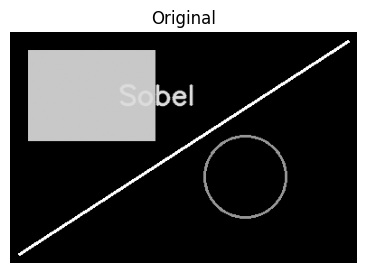

In [4]:

# Set this to your image file name if you have one in the same folder as the notebook
IMG_PATH = "example.jpg"

def make_synthetic(w=384, h=256):
    img = np.zeros((h, w), dtype=np.uint8)
    cv2.rectangle(img, (20, 20), (160, 120), 200, -1)
    cv2.circle(img, (260, 160), 45, 150, 2)
    cv2.line(img, (10, h-10), (w-10, 10), 255, 2)
    cv2.putText(img, "Sobel", (120, 80), cv2.FONT_HERSHEY_SIMPLEX, 1, 220, 2, cv2.LINE_AA)
    return img

if os.path.exists(IMG_PATH):
    img = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
    if img is None:
        img = make_synthetic()
else:
    img = make_synthetic()

print("Image shape:", img.shape)
plt.figure(figsize=(5,3))
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.show()



# Load image (make sure the image exists in your working directory)
# img = cv2.imread('input_image.jpg')
gray = img # cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_float = np.float32(gray)

## Harris Corner Detection

In [6]:
# Harris corner detection
img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
dst = cv2.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)

# Dilate results
dst = cv2.dilate(dst, None)

# Mark the detected corners on the original image
harris_img = img.copy()

harris_img[dst > 0.01 * dst.max()] = [0, 0, 255]

cv2.imshow('Harris Corners', harris_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

## Shi–Tomasi Corner Detection (Good Features to Track)

In [7]:
# Detect corners using Shi–Tomasi
good_corners = cv2.goodFeaturesToTrack(gray, maxCorners=100, qualityLevel=0.01, minDistance=10)

# Draw detected corners
shi_tomasi_img = img.copy()
for corner in good_corners:
    x, y = corner.ravel()
    cv2.circle(shi_tomasi_img, (int(x), int(y)), 3, (255,0,0), -1)

cv2.imshow('Shi–Tomasi Corners', shi_tomasi_img)
cv2.waitKey(0)
cv2.destroyAllWindows()